In [2]:

import mlflow
import pandas as pd
from wearable_affect.data import PROJECT_ROOT
from wearable_affect.detector import train_detector
from wearable_affect.tracking import TRACKING_URI

features = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "features.parquet")
detector = train_detector(features)
print(detector.metadata)

path = PROJECT_ROOT / "artifacts" / "stress_detector.joblib"
path.parent.mkdir(exist_ok=True)
detector.save(path)

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment("wesad-stress")
with mlflow.start_run(run_name="final-detector"):
    mlflow.log_params(detector.metadata)
    mlflow.log_artifact(str(path))

{'model': 'logreg', 'calibration_min': 5, 'window_s': 60, 'n_subjects': 15, 'n_training_windows': 880, 'sklearn_version': '1.9.1'}


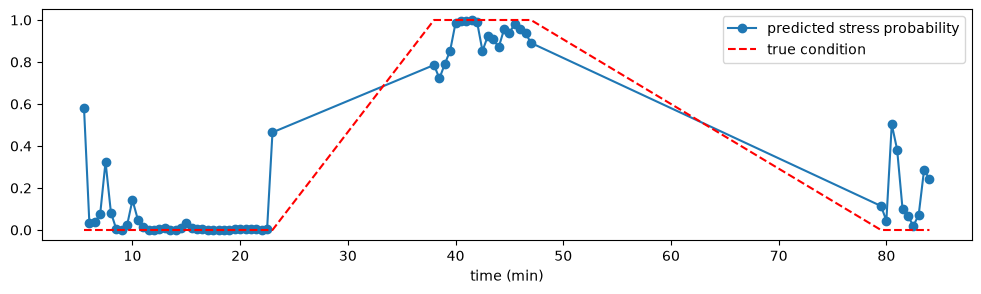

In [3]:
import matplotlib.pyplot as plt
from wearable_affect.data import DEFAULT_DATA_DIR, WRIST_FS, load_subject
from wearable_affect.detector import StressDetector
from wearable_affect.windows import make_windows

detector = StressDetector.load(path)
rec = load_subject(DEFAULT_DATA_DIR, "S2")
windows = make_windows(rec)

start = windows[0].start_s  # start of baseline
calibration = {name: rec.signals[name][start * fs : (start + 300) * fs] for name, fs in WRIST_FS.items()}
baseline = detector.baseline_from_calibration(calibration)

probs = [detector.predict_proba(w.signals, baseline) for w in windows]
plt.figure(figsize=(12, 3))
plt.plot([w.start_s / 60 for w in windows], probs, "o-", label="predicted stress probability")
plt.plot([w.start_s / 60 for w in windows], [w.target for w in windows], "r--", label="true condition")
plt.xlabel("time (min)")
plt.legend()
plt.show()

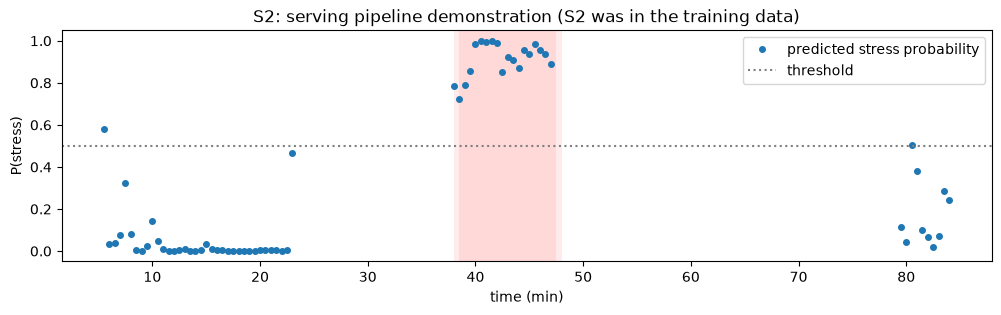

In [4]:
times = [w.start_s / 60 for w in windows]
fig, ax = plt.subplots(figsize=(12, 3))
for w in windows:
    if w.target == 1:
        ax.axvspan(w.start_s / 60, (w.start_s + 60) / 60, color="red", alpha=0.08, lw=0)
ax.plot(times, probs, "o", ms=4, label="predicted stress probability")
ax.axhline(detector.threshold, color="grey", ls=":", label="threshold")
ax.set_xlabel("time (min)")
ax.set_ylabel("P(stress)")
ax.set_title("S2: serving pipeline demonstration (S2 was in the training data)")
ax.legend(loc="upper right")
plt.show()